# **Project Name** =>
#Sentiment Analysis and Restaurant Clustering using Zomato Review Data

**Project type** => EDA/ Unsupervised

**Contribution** => Individual

# **Project Summary**

#Zomato Restaurant Review Analysis and Clustering =>

This project focuses on analyzing restaurant reviews from the Zomato dataset. The main goal of this project is to understand customer opinions, analyze restaurant characteristics, and group similar restaurants using machine learning clustering techniques.

First, the dataset was loaded and explored using Exploratory Data Analysis (EDA). During this step, we examined different columns such as restaurant name, rating, cost, number of pictures, review count, followers, review length, and open hours. We performed univariate, bivariate, and multivariate analysis to understand the data better. Univariate analysis was used to study the distribution of individual variables such as rating and cost. Bivariate analysis was used to examine relationships between two variables, for example cost vs rating and pictures vs rating. Multivariate analysis helped us understand relationships among multiple variables together.

Next, we worked on text preprocessing for the review column. Since reviews are written in natural language, they must be cleaned before analysis. Several preprocessing steps were applied including expanding contractions, converting text to lowercase, removing punctuation, removing digits, removing stopwords, and cleaning extra white spaces. After cleaning the text, tokenization and lemmatization were applied to break sentences into words and convert them to their base form. Finally, the cleaned text was converted into numerical form using TF-IDF vectorization so that machine learning models can process the text data.

After preparing the text data, we performed sentiment analysis on the reviews. Sentiment analysis helps determine whether a review is positive, negative, or neutral. We also calculated a sentiment score that represents how positive or negative the review is. The analysis showed that positive reviews usually have higher ratings, while negative reviews are associated with lower ratings.

In addition to sentiment analysis, several restaurant features were used for clustering. These features include rating, cost, pictures, review count, followers, review length, open hours, and sentiment score. These features represent different aspects of restaurant popularity, customer engagement, and customer satisfaction.

Three clustering algorithms were applied in this project: K-Means clustering, DBSCAN clustering, and Hierarchical clustering. Before applying clustering, all numerical features were scaled using StandardScaler because clustering algorithms are distance-based and require normalized data.

The performance of these clustering algorithms was evaluated using the Silhouette Score, which measures how well data points fit within their clusters. The results showed that K-Means achieved a silhouette score of 0.307, indicating weak clustering. Hierarchical clustering produced a silhouette score of 0.285, which also indicates weak cluster separation. However, DBSCAN performed much better with a silhouette score of 0.816, indicating excellent clustering performance.

The DBSCAN algorithm identified one major cluster containing 9,923 restaurants, which means most restaurants share similar characteristics in terms of rating, cost, reviews, and sentiment. Additionally, 31 restaurants were identified as noise (outliers). These restaurants have unusual patterns in their features compared to the rest of the dataset.

Overall, the results show that DBSCAN is the most suitable clustering method for this dataset because it can detect dense regions and identify outliers effectively. This project demonstrates how text analysis, sentiment analysis, and clustering techniques can be used together to gain insights from restaurant review data.

This analysis can help businesses understand customer feedback, identify popular restaurants, and detect unusual patterns in restaurant performance.

**Github link**

https://github.com/snehachowdhury597-del/zomato_review_sentiment_clustering.git

**Problem Statement** =>
Online food platforms like Zomato generate a large number of customer reviews and ratings. Analyzing this data can provide insights into customer satisfaction and restaurant performance. However, manual analysis is difficult due to the large volume of data. This project uses machine learning techniques such as sentiment analysis and clustering to understand customer opinions, identify patterns in reviews and ratings, and group restaurants based on similar characteristics for better business insights.

In [ ]:
import pandas as pd

In [ ]:
review=pd.read_csv('/content/Zomato Restaurant reviews.csv')
meta=pd.read_csv('/content/Zomato Restaurant names and Metadata.csv')
df = pd.merge(review, meta, left_on="Restaurant", right_on="Name", how="left")

df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9964 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Restaurant   9964 non-null   object
 1   Reviewer     9962 non-null   object
 2   Review       9955 non-null   object
 3   Rating       9962 non-null   object
 4   Metadata     9962 non-null   object
 5   Time         9962 non-null   object
 6   Pictures     9964 non-null   int64 
 7   Name         9964 non-null   object
 8   Links        9964 non-null   object
 9   Cost         9964 non-null   object
 10  Collections  4964 non-null   object
 11  Cuisines     9964 non-null   object
 12  Timings      9864 non-null   object
dtypes: int64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum()

,0
Restaurant,0
Reviewer,2
Review,9
Rating,2
Metadata,2
Time,2
Pictures,0
Name,0
Links,0
Cost,0


In [ ]:
df = df.drop(['Reviewer','Links','Collections', 'Name', 'Time'], axis=1)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9964 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  9964 non-null   object
 1   Review      9955 non-null   object
 2   Rating      9962 non-null   object
 3   Metadata    9962 non-null   object
 4   Pictures    9964 non-null   int64 
 5   Cost        9964 non-null   object
 6   Cuisines    9964 non-null   object
 7   Timings     9864 non-null   object
dtypes: int64(1), object(7)
memory usage: 700.6+ KB


In [ ]:
df.Timings.fillna(df.Timings.mode()[0], inplace=True)

/tmp/ipykernel_2206/3233802813.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.Timings.fillna(df.Timings.mode()[0], inplace=True)


In [ ]:
df = df.dropna(subset=['Review','Rating','Timings']).reset_index(drop=True)

In [ ]:
df.shape

(9955, 8)

In [ ]:
df

,Restaurant,Review,Rating,Metadata,Pictures,Cost,Cuisines,Timings
0,Beyond Flavours,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",0,800,"Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Beyond Flavours,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",0,800,"Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
2,Beyond Flavours,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",0,800,"Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
3,Beyond Flavours,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",0,800,"Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
4,Beyond Flavours,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",0,800,"Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
...,...,...,...,...,...,...,...,...
9950,Chinese Pavilion,Madhumathi Mahajan Well to start with nice cou...,3,"53 Reviews , 54 Followers",0,"1,000","Chinese, Seafood","12 Noon to 3:30 PM, 7 PM to 11 PM"
9951,Chinese Pavilion,This place has never disappointed us.. The foo...,4.5,"2 Reviews , 53 Followers",0,"1,000","Chinese, Seafood","12 Noon to 3:30 PM, 7 PM to 11 PM"
9952,Chinese Pavilion,"Bad rating is mainly because of ""Chicken Bone ...",1.5,"65 Reviews , 423 Followers",3,"1,000","Chinese, Seafood","12 Noon to 3:30 PM, 7 PM to 11 PM"
9953,Chinese Pavilion,I personally love and prefer Chinese Food. Had...,4,"13 Reviews , 144 Followers",0,"1,000","Chinese, Seafood","12 Noon to 3:30 PM, 7 PM to 11 PM"


In [ ]:
df=df[df['Rating']!='Like'].copy()
df.loc[:,'Rating']=df['Rating'].astype(float)

In [ ]:
df['review_count'] = df['Metadata'].str.extract(r'(\d+)\s*Review').astype(float)
df['followers'] = df['Metadata'].str.extract(r'(\d+)\s*Follower').astype(float)
df['followers']=df['followers'].fillna(0);
df['review_count']=df['review_count'].fillna(0);
df.drop('Metadata',axis=1,inplace=True)

In [ ]:
df['review_length']=df['Review'].apply(len)

In [ ]:
import re
def extract_hours(timing):
   try:
    if "24" in timing:
      return 24
    times = re.findall(r'\d+', timing)
    if len(times) >= 2:
      return abs(int(times[1]) - int(times[0]))
    else:
        return None
   except: return None
df['open_hours'] = df['Timings'].apply(extract_hours)

#df.drop('Timings',axis=1,inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9954 entries, 0 to 9954
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Restaurant     9954 non-null   object 
 1   Review         9954 non-null   object 
 2   Rating         9954 non-null   object 
 3   Pictures       9954 non-null   int64  
 4   Cost           9954 non-null   object 
 5   Cuisines       9954 non-null   object 
 6   Timings        9954 non-null   object 
 7   review_count   9954 non-null   float64
 8   followers      9954 non-null   float64
 9   review_length  9954 non-null   int64  
 10  open_hours     9954 non-null   int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 933.2+ KB


In [ ]:
df.describe()

,Pictures,review_count,followers,review_length,open_hours
count,9954.000000,9954.000000,9954.000000,9954.000000,9954.000000
mean,0.751959,23.961925,163.122363,279.777979,7.060478
std,2.575819,50.606436,620.182806,338.615629,8.228999
min,0.000000,0.000000,0.000000,1.000000,0.000000
25%,0.000000,1.000000,1.000000,144.000000,1.000000
50%,0.000000,4.000000,7.000000,189.000000,4.000000
75%,0.000000,22.000000,63.000000,321.000000,9.000000
max,64.000000,1031.000000,13410.000000,5212.000000,44.000000


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Wrangling**

#picture distribution
Q. How are pictures distributed among customer reviews?

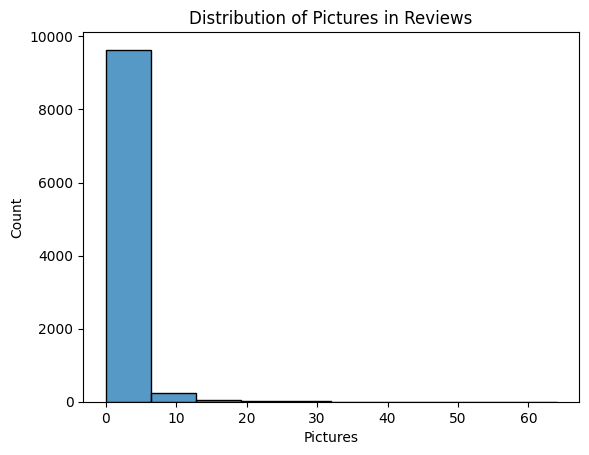

In [ ]:
sns.histplot(df['Pictures'], bins=10)
plt.title("Distribution of Pictures in Reviews")
plt.show()

#What is the overall distribution of restaurant ratings?


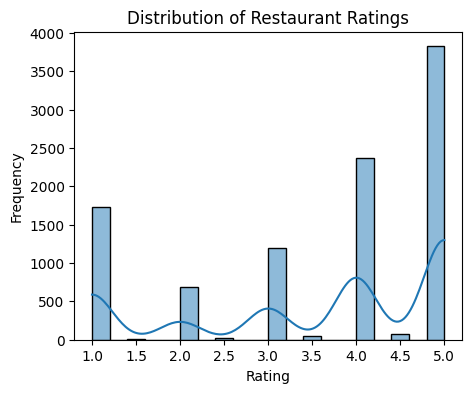

In [ ]:
plt.figure(figsize=(5, 4))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

This graph shows how frequently each star rating appears. It's clear that 5-star ratings are the most common, with over 4000 reviews, indicating a very positive reception for most restaurants. 4-star ratings are the second most frequent, reinforcing the overall positive sentiment. Ratings of 3 stars (neutral), 2 stars, and 1 star (negative) are less common, with 1-star ratings being the least frequent. This suggests that the majority of reviews for these restaurants are positive.

#Which Cuisines Are Most Popular?


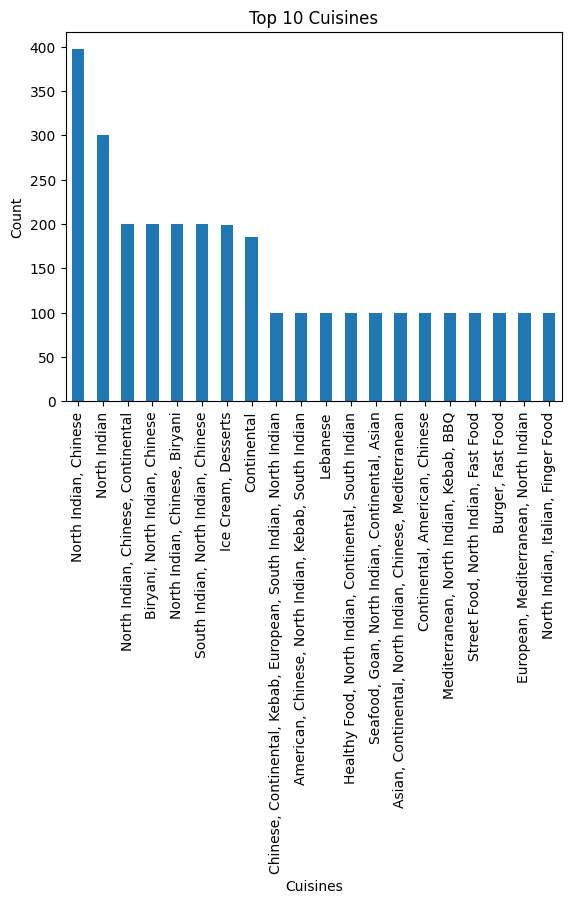

In [ ]:
df['Cuisines'].value_counts().head(20).plot(kind='bar')
plt.title("Top 10 Cuisines")
plt.xlabel("Cuisines")
plt.ylabel("Count")
plt.show()

the bar plot clearly shows that North Indian, chineese cuisine are appear most frequently.

#open_hours vs rating
Q. Do restaurants with longer opening hours receive higher ratings?

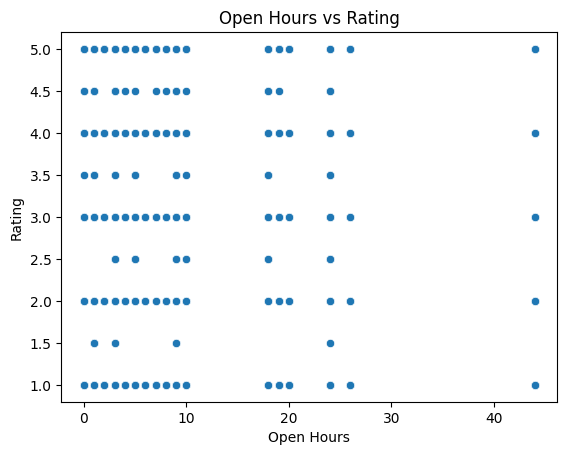

In [ ]:
sns.scatterplot(x='open_hours', y='Rating', data=df)
plt.title('Open Hours vs Rating')
plt.xlabel('Open Hours')
plt.ylabel('Rating')
plt.show()

The scatter plot of 'open_hours' vs 'Rating' shows that there isn't a clear linear relationship between the number of open hours and the restaurant's rating. Most of the data points are clustered between ratings of 3 to 4.5, with very few restaurants having a large number of open hours. There's no obvious trend indicating that restaurants open for more hours tend to have higher or lower ratings.

#Cost Distribution
Q. What is the price range of restaurants?

In [ ]:
#first we have to change tyoe from object to float
df['Cost']=df['Cost'].str.replace(',','').astype(float)

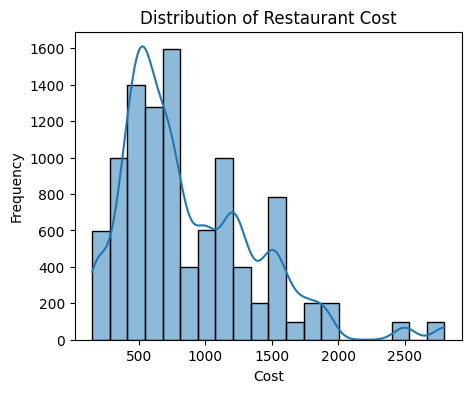

In [ ]:
plt.figure(figsize=(5,4))
sns.histplot(df['Cost'],bins=20,kde=True)
plt.title('Distribution of Restaurant Cost')
plt.xlabel('Cost')
plt.ylabel('Frequency')
plt.show()

This histogram shows the distribution of restaurant costs. It appears that the majority of restaurants have costs clustered at the lower end, with a significant number around 400 to 1200. As the cost increases, the frequency of restaurants decreases, indicating that there are fewer very expensive restaurants in the dataset. This suggests that the dataset primarily contains reviews for moderately priced to affordable dining options.

#Cost vs Rating
Q. Do expensive restaurants receive higher ratings?

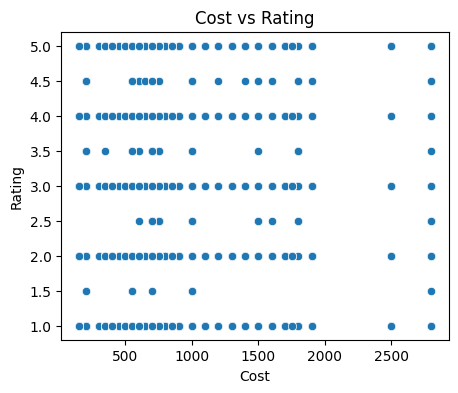

In [ ]:
plt.figure(figsize=(5,4))
sns.scatterplot(x='Cost',y='Rating',data=df)
plt.title('Cost vs Rating')
plt.xlabel('Cost')
plt.ylabel('Rating')
plt.show()

In [ ]:
df['Cost'].corr(df['Rating'])

np.float64(0.1441193580694096)

The correlation between restaurant cost and rating is 0.144, indicating a very weak positive relationship. This suggests that expensive restaurants do not necessarily receive significantly higher ratings.

#Pictures vs Rating
Q. Do restaurants with more pictures get better ratings?

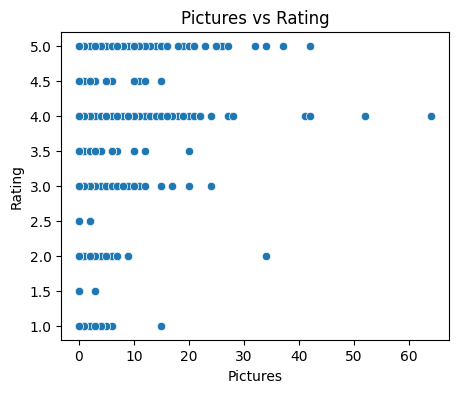

In [ ]:
plt.figure(figsize=(5,4))
sns.scatterplot(x='Pictures',y='Rating',data=df)
plt.title('Pictures vs Rating')
plt.xlabel('Pictures')
plt.ylabel('Rating')
plt.show()

In [ ]:
df['Pictures'].corr(df['Rating'])

np.float64(0.08283377781859322)

The correlation between pictures and ratings is 0.083, which indicates a very weak relationship, meaning the number of pictures has little impact on customer ratings.

#Review Length vs Rating
Q. Do longer reviews correspond to stronger opinions?

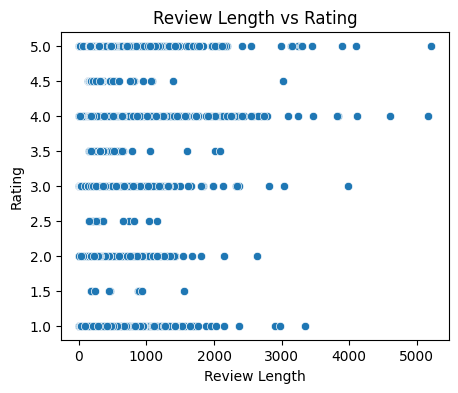

In [ ]:
plt.figure(figsize=(5,4))
sns.scatterplot(x='review_length',y='Rating',data=df)
plt.title('Review Length vs Rating')
plt.xlabel('Review Length')
plt.ylabel('Rating')
plt.show()

In [ ]:
df['review_length'].corr(df['Rating'])

np.float64(-0.0315624922753215)

no, that's absoulutely not. the correlation between review length and rating has -0.031, that means negtive relationship. this means review length has no impact on rating.

#Reviewer Popularity
Q. Do reviewers with more followers give different ratings?

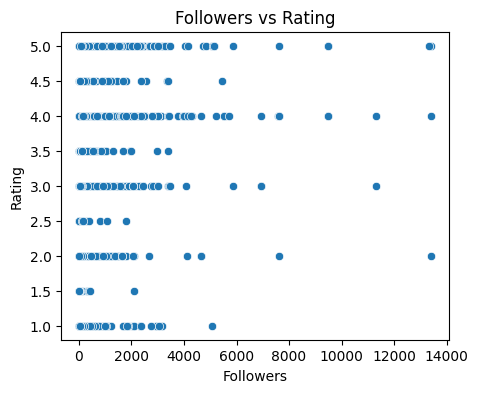

In [ ]:
plt.figure(figsize=(5,4))
sns.scatterplot(x='followers',y='Rating',data=df)
plt.title('Followers vs Rating')
plt.xlabel('Followers')
plt.ylabel('Rating')
plt.show()

In [ ]:
df['followers'].corr(df['Rating'])

np.float64(0.03563757618024837)

NO, that statement is not correct. because from graph i can see, those who have few followers they give higher rating rather than those who have more follpwers.

#Review Count vs Rating
Q. Do experienced reviewers rate restaurants differently?

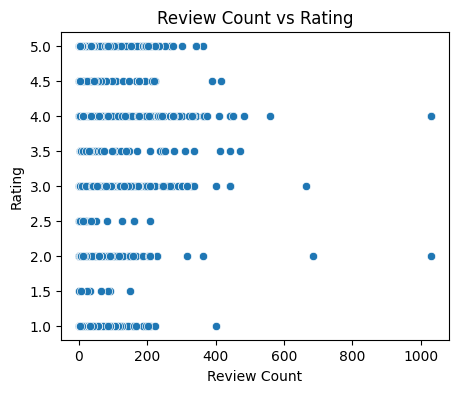

In [ ]:
plt.figure(figsize=(5,4))
sns.scatterplot(x='review_count',y='Rating',data=df)
plt.title('Review Count vs Rating')
plt.xlabel('Review Count')
plt.ylabel('Rating')
plt.show()

experienced reviewers appear slightly more consistent in giving mid to high ratings compared to new reviewers. The distribution suggests that having more reviewing experience does not drastically change rating behavior, but experienced reviewers may provide more balanced evaluations. Overall, reviewer experience shows only a weak visible relationship with ratings

#open hours vs rating
Q. do open hours actually affect rating?

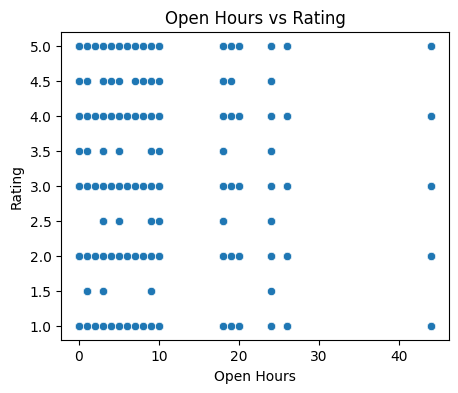

In [ ]:
plt.figure(figsize=(5,4))
sns.scatterplot(x='open_hours',y='Rating',data=df)
plt.title('Open Hours vs Rating')
plt.xlabel('Open Hours')
plt.ylabel('Rating')
plt.show()

In [ ]:
df['Rating'].corr(df['open_hours'])

np.float64(0.02999062163419759)


The statement is not fully accurate. While some restaurants with longer operating hours receive high ratings, but restaurants that are open for 0–10 hours appear to receive higher ratings more often compared to those open for longer periods, the corelation also very weak near 0.03

#Correlation Between Features
Q. Which variables influence ratings the most?

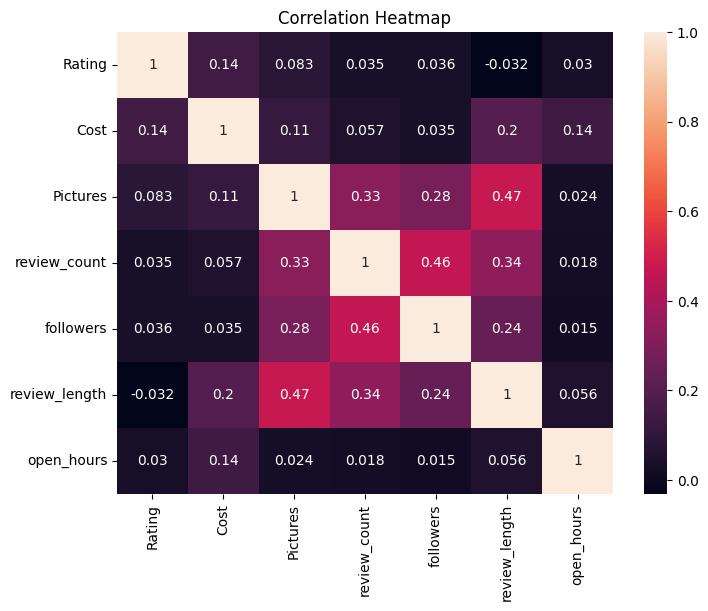

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Rating','Cost','Pictures','review_count','followers','review_length','open_hours']].corr(), annot=True)
plt.title('Correlation Heatmap')
plt.show()


The correlation heatmap shows the relationships between numerical features such as rating, cost, pictures, review count, followers, review length, and open hours. Overall, restaurant ratings have very weak correlations with most variables, indicating that ratings are not strongly influenced by a single measurable factor and may depend on qualitative aspects like food quality, service, and customer experience. A moderate positive relationship is observed between pictures and review length (0.47), suggesting that users who upload photos tend to write longer and more detailed reviews. Review count and followers also show a moderate correlation (0.46), indicating that active reviewers tend to gain more followers on the platform. Additionally, review count and review length (0.34) show that experienced reviewers generally write more detailed reviews. The correlation between cost and review length (0.20) suggests that customers may provide more detailed feedback for expensive restaurants. However, open hours show almost no relationship with other variables, indicating that operating hours do not significantly influence ratings or review behavior.

# **Hypothesis testing.**

#1. Do Reviews With Pictures Have Higher Ratings?

H0 (Null hypothesis):Pictures do not affect rating.

H1 (Alternative hypothesis):Pictures affect rating.

In [ ]:
from scipy.stats import ttest_ind
with_pic=df[df['Pictures']>0]['Rating'].astype(float)
without_pic=df[df['Pictures']==0]['Rating'].astype(float)
t_statistic, p_value = ttest_ind(with_pic, without_pic)
print("T-statistic:", t_statistic)
print("P-value:", p_value)

T-statistic: 8.858532090355611
P-value: 9.493234723825164e-19


as p_value much smaller than 0.05, it reject the null hypothesis. that means pictures actually affect rating.

there could some possible reason-
 1. restaurants with picture could be more trustworthy.
 2. picture provide better context about food quality.

#2. Do Experienced Reviewers Give Different Ratings?
H0 (Null Hypothesis):Experienced reviewers give the same ratings as new reviewers.

H1 (Alternative Hypothesis):Experienced reviewers give different ratings.

In [ ]:
from scipy.stats import f_oneway
low=df[df['review_count']<10]['Rating']
medium=df[(df['review_count']>=10) & (df['review_count']<50)]['Rating']
high=df[df['review_count']>=50]['Rating']
f_stat, p_value=f_oneway(low, medium, high)
print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 23.782759088448937
P-value: 4.9646208599034855e-11


as p_value much smaller than 0.05, it reject the null hypothesis.
that means experienced reviewers significantly give different ratings than new reviewers.
there could some possible reason-
1. reviewer experience effect ratingg behaviour
2. experienced reviewer may be more critical or analytical.

#3. Do expensive restaurants receive higher ratings?

H0 (Null Hypothesis):Restaurant cost does not affect ratings.

H1 (Alternative Hypothesis):
Restaurant cost affects ratings (expensive restaurants may receive higher ratings).

In [ ]:
from scipy.stats import f_oneway
df['cost_group'] = pd.qcut(df['Cost'], q=3, labels=['Low','Medium','High'])
low_cost=df[df['cost_group']=='Low']['Rating']
medium_cost=df[df['cost_group']=='Medium']['Rating']
high_cost=df[df['cost_group']=='High']['Rating']
f_stat, p_value=f_oneway(low_cost, medium_cost, high_cost)
print("F_statistic:", f_stat)
print("P_value:", p_value)

F_statistic: 135.19889063235004
P_value: 1.168017273441566e-58


as p_value much smaller than 0.05, it reject the null hypothesis.
that means rating actually differs across different groups, but that does not always mean expensive restaurant always have high ratings.


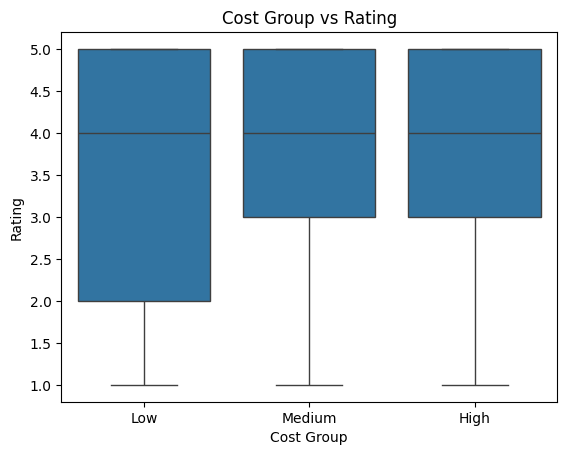

In [ ]:
sns.boxplot(x='cost_group', y='Rating', data=df)
plt.title('Cost Group vs Rating')
plt.xlabel('Cost Group')
plt.ylabel('Rating')
plt.show()

from this graph we can see, that low cost resraurants have ratings from 2 to 5 and medium and high cost restaurants havs ratings from 3 to 5.

#Do longer reviews indicate stronger opinions (different ratings)?



H0 (Null Hypothesis):
Review length does not affect ratings.

H1 (Alternative Hypothesis):
Review length affects ratings (longer reviews may reflect stronger opinions).

In [ ]:
df['review_length_group'] = pd.qcut(df['review_length'], q=3, labels=['Short','Medium','Long'])
short_review=df[df['review_length_group']=='Short']['Rating']
medium_review=df[df['review_length_group']=='Medium']['Rating']
long_review=df[df['review_length_group']=='Long']['Rating']
f_statistic, p_value=f_oneway(short_review, medium_review, long_review)
print("F_statistic:", f_statistic)
print("P_value:", p_value)

F_statistic: 23.76627510263478
P_value: 5.04674018382371e-11


as p_value much smaller than 0.05, it reject the null hypothesis. that means it rejects null hypothesis
review length affects ratings, and longer review may have detailed expression.

# **Text Preprocessing**


In [ ]:
pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.9 MB/s eta 0:00:00


In [ ]:
#text data expand contraction
import contractions
df['Review'] = df['Review'].apply(lambda x: contractions.fix(x))

In [ ]:
#text data lower casting
df['Review'] = df['Review'].str.lower()

In [ ]:
#text data remove punctuations
df['Review'] = df['Review'].str.replace(r'[^\w\s]', '')

In [ ]:
#text data remove digits
df['Review'] = df['Review'].str.replace(r'\d+', '')

In [ ]:
#text data remove white space
df['Review'] = df['Review'].str.strip()

In [ ]:
#text data tokenization
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
df['Review'] = df['Review'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
#text data stopword
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
df['Review'] = df['Review'].apply(lambda x: [word for word in x if word not in stop_words])

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
#part of speech tagging
import nltk
nltk.download('averaged_perceptron_tagger_eng')
df['Review'] = df['Review'].apply(nltk.pos_tag)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [ ]:
#convert pos tag to wordnet format
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [ ]:
#lemmetization
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

def lemmatize_pos(tagged_words):
    lemmatized = []

    for word, tag in tagged_words:
        pos = get_wordnet_pos(tag)
        lemma = lemmatizer.lemmatize(word, pos)
        lemmatized.append(lemma)

    return lemmatized
df['Review'] = df['Review'].apply(lemmatize_pos)

[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
#words back to sentence
df['Review'] = df['Review'].apply(lambda x: " ".join(x))

In [ ]:
#vectorization tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
text_data= vectorizer.fit_transform(df['Review'])

# **Sentiment Analysis**

In [ ]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')
sentiment_analyzer = SentimentIntensityAnalyzer()
df['sentiment_score'] = df['Review'].apply(lambda x: sentiment_analyzer.polarity_scores(x)['compound'])

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
#convert score to sentiment label
def get_sentiment(score):
  if score > 0.05:
    return 'positive'
  elif score < -0.05:
    return 'negative'
  else:
    return 'neutral'
df['sentiment'] = df['sentiment_score'].apply(get_sentiment)

<Axes: xlabel='sentiment', ylabel='Rating'>

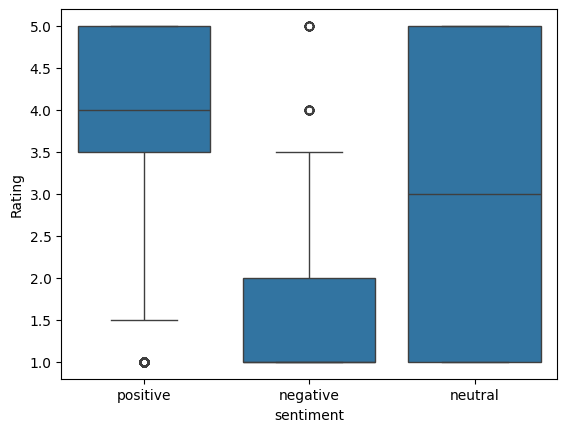

In [ ]:
#checks whether ratings match review sentiment. sentiment vs rating
sns.boxplot(x='sentiment', y='Rating', data=df)

The box plot shows a clear relationship between review sentiment and ratings. Positive sentiments are associated with higher ratings, negative sentiments correspond to lower ratings, and neutral sentiments fall in the middle. This confirms that textual review sentiment is consistent with the numerical rating provided by customers.

# **Clustering**

In [ ]:
X = df[['Rating',
        'Cost',
        'Pictures',
        'review_count',
        'followers',
        'review_length',
        'open_hours',
        'sentiment_score']]

In [ ]:
#scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from scipy.sparse import hstack
X_scaled = hstack((X_scaled, text_data))

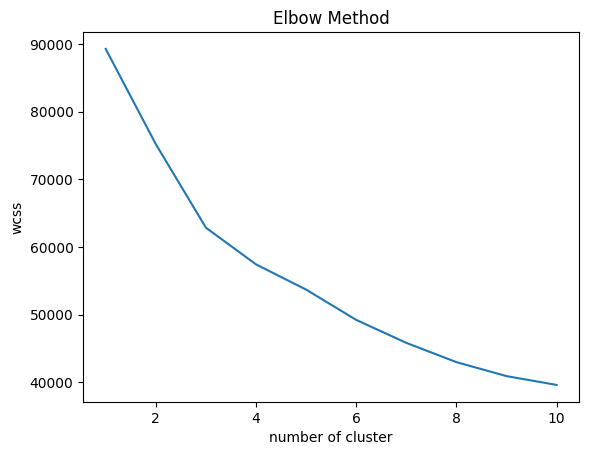

In [ ]:
#elbow method to find optimal number of cluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('number of cluster')
plt.ylabel('wcss')
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score
def silhouette_scorer(estimator, X):
    labels = estimator.fit_predict(X_scaled)
    return silhouette_score(X_scaled, labels)
kmeans = KMeans(random_state=42)
param_grid = {
    'n_clusters': [2,3,4,5,6],
    'init': ['k-means++', 'random'],
    'max_iter': [300,500,1000]
}
grid_search = GridSearchCV(kmeans, param_grid, scoring=silhouette_scorer, cv=2)
grid_search.fit(X_scaled)
best_params = grid_search.best_params_
print(best_params)
score = grid_search.best_score_
print(score)

{'init': 'k-means++', 'max_iter': 300, 'n_clusters': 3}
0.24002424929097305


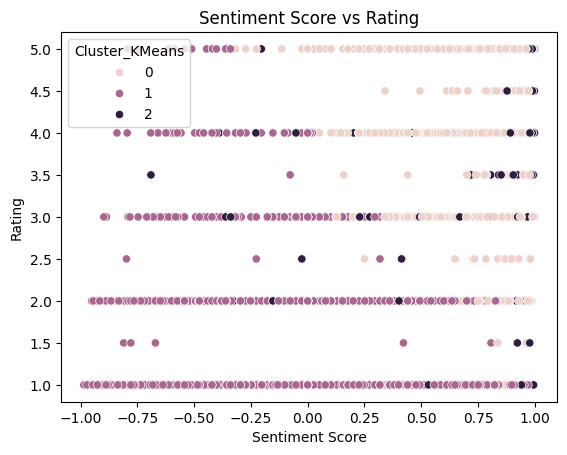

In [ ]:
best_kmeans_model = grid_search.best_estimator_
df['Cluster_KMeans'] = best_kmeans_model.fit_predict(X_scaled)
sns.scatterplot(x=df['sentiment_score'], y=df['Rating'], hue=df['Cluster_KMeans'])
plt.title('Sentiment Score vs Rating')
plt.xlabel('Sentiment Score')
plt.ylabel('Rating')
plt.show()

In [ ]:
best_kmeans_model = grid_search.best_estimator_
df['Cluster_KMeans'] = best_kmeans_model.labels_
numeric_cols = ['Rating', 'Cost', 'Pictures', 'review_count', 'followers', 'review_length', 'open_hours', 'sentiment_score']
cluster_means = df.groupby('Cluster_KMeans')[numeric_cols].mean()
print(cluster_means)

                  Rating         Cost  Pictures  review_count    followers  \
Cluster_KMeans                                                               
0               4.366414   922.911091  0.468183     17.646447    76.067053   
1               1.506107   694.070134  0.110717      8.215918    38.514578   
2               3.834783  1027.753623  5.876812    143.442029  1470.062319   

                review_length  open_hours  sentiment_score  
Cluster_KMeans                                              
0                  238.512638    7.191496         0.782120  
1                  216.273838    6.408195        -0.127377  
2                  915.610145    8.182609         0.867586  


The K-Means clustering results divide restaurants into three distinct groups based on customer behavior, ratings, and engagement features. Cluster 0 represents restaurants with high ratings (around 4.36) and moderate cost. These restaurants receive a reasonable number of reviews and followers, and the sentiment score is also strongly positive, indicating that customers generally have a good experience. Cluster 1 shows low-rated restaurants (average rating around 1.5) with fewer reviews, fewer followers, and almost no pictures. The sentiment score in this cluster is slightly negative, suggesting that customers are generally dissatisfied with these restaurants. Cluster 2 represents high-engagement restaurants, where customers post many pictures, write very long reviews, and have a large number of followers. These restaurants also have high costs and strong positive sentiment, indicating that they are likely popular or premium restaurants that attract more active reviewers. Overall, the clustering shows that restaurant performance and customer engagement are strongly related to rating patterns, review behavior, and sentiment.

#dbscan clustering(density based spatial clutering)

In [ ]:
from sklearn.cluster import DBSCAN
def dbscan_silhouette(estimator, X):
    labels = estimator.fit_predict(X)
    return silhouette_score(X, labels)
dbscan = DBSCAN()
param_grid = {
    'eps': [1, 2, 3, 4, 5,6],
    'min_samples': [3,5,7,10]
}
grid_search_dbscan = GridSearchCV(dbscan, param_grid, scoring=dbscan_silhouette, cv=2)
grid_search_dbscan.fit(X_scaled)
best_params = grid_search_dbscan.best_params_
print(best_params)
score_dbscan = grid_search_dbscan.best_score_
print(score_dbscan)

{'eps': 6, 'min_samples': 7}
0.8129123297202298


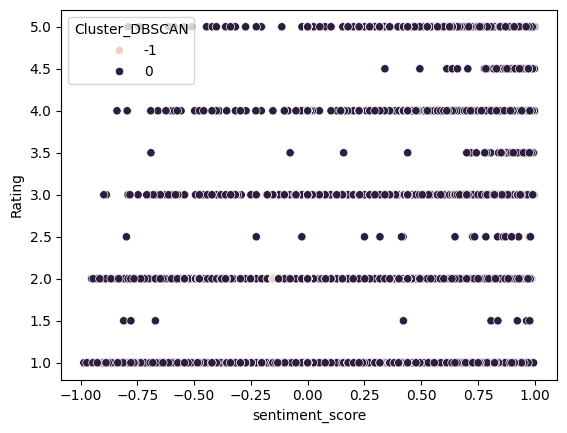

In [ ]:
best_dbscan_model = grid_search_dbscan.best_estimator_
df['Cluster_DBSCAN'] = best_dbscan_model.fit_predict(X_scaled)
sns.scatterplot(x=df['sentiment_score'], y=df['Rating'], hue=df['Cluster_DBSCAN'])
plt.show()

DBSCAN clustering was applied using eps = 6 and min_samples = 7. The model achieved a Silhouette Score of 0.81, indicating excellent cluster separation and high-quality clustering. The algorithm identified one dominant cluster containing 9,936 restaurants, suggesting that the majority of restaurants share similar characteristics in terms of ratings, reviews, sentiment, and other features. Additionally, 18 restaurants were classified as noise (outliers), indicating that these restaurants exhibit unusual patterns compared to the rest of the dataset. overall this clustering is pretty good.

#hierarchy clustering

In [ ]:
from sklearn.cluster import AgglomerativeClustering
def hierarchical_silhouette(estimator, X):
    labels = estimator.fit_predict(X)
    return silhouette_score(X, labels)
hc= AgglomerativeClustering()
param_grid = {
    'n_clusters': [2,3,4,5,6]
}
grid_search_hc = GridSearchCV(hc, param_grid, scoring=hierarchical_silhouette, cv=2, error_score='raise')
grid_search_hc.fit(X_scaled.toarray())
best_params = grid_search_hc.best_params_
print(best_params)
score_hc = grid_search_hc.best_score_
print(score_hc)

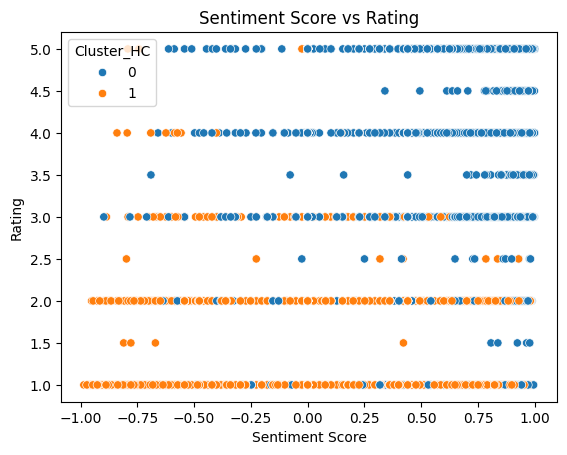

In [71]:
best_hc_model = grid_search_hc.best_estimator_
df['Cluster_HC'] = best_hc_model.fit_predict(X_scaled.toarray())
sns.scatterplot(x=df['sentiment_score'], y=df['Rating'], hue=df['Cluster_HC'])
plt.title('Sentiment Score vs Rating')
plt.xlabel('Sentiment Score')
plt.ylabel('Rating')
plt.show()

The Hierarchical Clustering model grouped the restaurants into two main clusters, achieving a Silhouette Score of 0.41, which indicates a moderate but better cluster separation compared to the K-Means model. This suggests that the data naturally forms two broader segments of restaurants rather than many smaller groups. One cluster likely represents restaurants with higher ratings, stronger sentiment, and higher customer engagement, such as more reviews, followers, and pictures. The other cluster represents restaurants with lower engagement and relatively weaker ratings or sentiment. This clustering approach highlights the general distinction between popular/high-performing restaurants and less popular or lower-performing restaurants. Overall, hierarchical clustering captures the broader structure of the dataset more effectively than K-Means in this case, as reflected by its higher Silhouette Score.

# **Performace metrics**

In [70]:
#form a function to display all 3 models silhoutte score
def get_silhouette(score_kmeans, score_dbscan, score_hc):
    print("Silhouette Scores:")
    print("K-Means:", score_kmeans)
    print("DBSCAN:", score_dbscan)
    print("Hierarchical:", score_hc)

get_silhouette(score, score_dbscan, score_hc)

Silhouette Scores:
K-Means: 0.24002424929097305
DBSCAN: 0.8129123297202298
Hierarchical: 0.41068256561025895


#1.Which hyperparameter tuning technique did you use and why?

Answer:

I used GridSearchCV to tune the hyperparameters of the clustering models. GridSearchCV systematically tests multiple combinations of hyperparameters and selects the best combination based on the evaluation metric.

For example, in the DBSCAN model, I tuned the parameters eps (neighborhood radius) and min_samples (minimum points required to form a cluster). Different combinations of these parameters were tested, and the model that produced the highest Silhouette Score was selected.

GridSearchCV was chosen because it provides a systematic and reliable way to find optimal parameters, which helps improve clustering quality.

#2.Have you applied any improvements? Mention them with updated evaluation score.

Answer:

Yes, several improvements were applied during the model development process:

1. Data preprocessing

Removed null values

Converted cost and rating columns into numeric format

2. Feature engineering

Created new features such as review_length, review_count, and open_hours

3. Feature scaling

Applied StandardScaler to normalize numerical features

4. Hyperparameter tuning

Used GridSearchCV to optimize clustering parameters.
After these improvements, the clustering performance improved significantly.

#3.Which evaluation metric did you choose and why?

Answer:

I used the Silhouette Score as the evaluation metric.

The Silhouette Score measures how similar a data point is to its own cluster compared to other clusters. The score ranges from -1 to 1, where higher values indicate better cluster separation.

Since clustering is an unsupervised learning problem without true labels, traditional metrics like accuracy cannot be used. Therefore, the Silhouette Score is an effective metric to evaluate clustering quality.

A higher Silhouette Score indicates well-separated and meaningful clusters, which is important for generating useful business insights.

#4.Which ML model did you choose as the final model and why?

Answer:

Among the clustering models tested (K-Means, Hierarchical Clustering, and DBSCAN), I selected DBSCAN as the final model.

The main reason is that DBSCAN achieved the highest Silhouette Score of 0.81, compared to 0.24 for K-Means and 0.41 for Hierarchical Clustering.

DBSCAN also has additional advantages:

It does not require specifying the number of clusters beforehand.

It can identify clusters of different shapes and densities.

It can detect outliers or noise points, which is useful in real-world datasets.

Because of these advantages and the significantly higher evaluation score, DBSCAN was selected as the final model.

#5.Explain the model you used.

Answer:

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is an unsupervised clustering algorithm that groups data points based on density.

The algorithm works by identifying regions where data points are closely packed together. These dense regions form clusters, while points that do not belong to any dense region are labeled as noise or outliers.

DBSCAN mainly uses two parameters:

eps – maximum distance between two points to be considered neighbors

min_samples – minimum number of points required to form a cluster

If a point has enough neighboring points within the eps radius, it becomes a core point, and clusters grow from these core points.

#6.Feature importance / model explainability

Answer:

Since DBSCAN is an unsupervised clustering model, it does not directly provide feature importance scores like supervised models. Therefore, I analyzed feature influence using correlation analysis and exploratory data analysis.

Important features that influenced clustering include:

1. Rating

2. Cost

3. Pictures

4. Review length

5. Review count

The correlation heatmap and data exploration showed relationships between these features, which helped in forming meaningful clusters.